## 1. وارد کردن کتابخانه‌ها

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-0cjkrjl0 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. بارگذاری مجموعه‌داده

In [2]:
# Load the diabetes dataset
df = pd.read_csv('diabetes.csv')

## 3. بررسی اولیه داده‌ها

In [3]:
# Display the first five rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Display column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Display descriptive statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 4. بررسی و مدیریت مقادیر صفر غیرمنطقی

In [6]:
# Columns in which zero is considered an invalid medical value
cols_with_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Replace invalid zero values with missing values
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# Display the number of missing values in each column
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 5. جداسازی ویژگی‌ها و متغیر هدف

In [7]:
# Separate input features from the target variable
X = df.drop('Outcome', axis=1)
y = df['Outcome']

## 6. تقسیم داده‌ها به آموزش و آزمون

In [8]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (614, 8)
Testing data shape: (154, 8)


## 7. جایگزینی مقادیر گمشده

In [9]:
# Create a median imputer
imputer = SimpleImputer(strategy='median')

# Fit the imputer only on training data
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Apply the same transformation to testing data
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## 8. استانداردسازی ویژگی‌ها

In [10]:
# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. تعریف مدل‌های یادگیری ماشین

In [11]:
# Define the machine learning models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=7
    ),

    'SVM': SVC(
        kernel='rbf',
        random_state=42
    )
}

## 10. آموزش و ارزیابی مدل‌ها

In [12]:
# Store the evaluation results and trained models
results = []
trained_models = {}

for name, model in models.items():

    # Use scaled data for models that are sensitive to feature scale
    if name in ['Logistic Regression', 'KNN', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Tree-based models do not require scaled data
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

    trained_models[name] = model

## 11. مقایسه نتایج مدل‌ها

In [13]:
# Convert the results into a DataFrame
results_df = pd.DataFrame(results)

# Sort models by F1-score
results_df = results_df.sort_values(
    by='F1-score',
    ascending=False
)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-score
1        Decision Tree    0.7597     0.6393  0.7222    0.6783
2        Random Forest    0.7532     0.6818  0.5556    0.6122
4                  SVM    0.7403     0.6522  0.5556    0.6000
3                  KNN    0.7273     0.6250  0.5556    0.5882
0  Logistic Regression    0.7078     0.6000  0.5000    0.5455


## 12. انتخاب بهترین مدل

In [14]:
# Select the model with the highest F1-score
best_model_name = results_df.iloc[0]['Model']

print("Best model:", best_model_name)

Best model: Decision Tree


## 13. پیش‌بینی با بهترین مدل

In [15]:
# Get the trained best model
best_model = trained_models[best_model_name]

# Use the correct version of the testing data
if best_model_name in ['Logistic Regression', 'KNN', 'SVM']:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

## 14. گزارش طبقه‌بندی

In [16]:
# Display the classification report
print(classification_report(
    y_test,
    y_pred_best,
    target_names=['Non-diabetic', 'Diabetic']
))

              precision    recall  f1-score   support

Non-diabetic       0.84      0.78      0.81       100
    Diabetic       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



## 15. رسم ماتریس اغتشاش

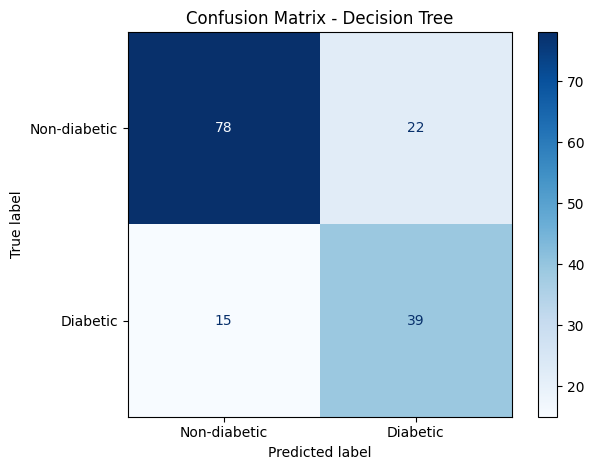

In [17]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-diabetic', 'Diabetic']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - ' + best_model_name)
plt.tight_layout()
plt.show()